In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from files.pezw2 import pezw2
from IPython.display import Audio      # βιβιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)
from scipy.io import wavfile

Σε αυτή την άσκηση θα χρησιμοποιήσετε αρκετά μια custom συνάρτηση που ονομάζεται pezw2, η οποία τυπώνει μερικά ενδιαφέροντα γραφήματα σχετικά με μια συνάρτηση μεταφοράς $$H(z) = \frac{P(z)}{Q(z)}$$

Δείτε παρακάτω τι κάνει και πως συντάσσεται.

In [2]:
help(pezw2)

Help on function pezw2 in module files.pezw2:

pezw2(B, A)
    pezw2(B,A)
    
    Η PEZW2(B,A) σχεδιάζει
    (a) το μέτρο του H(z),
    (b) τα μηδενικά και τους πόλους (με τον μοναδιαίο κύκλο ως αναφορά),
    (c) το φάσμα πλάτους και φάσης του συστήματος,
    (d) την κρουστική απόκριση h[n] (τα πρώτα 100 δείγματα), και
    (e) την καθυστέρηση ομάδας του συστήματος.
    
    Τα B και A είναι πολυώνυμα ως προς z^-1:
    B(z): διάνυσμα που περιέχει τους συντελεστές του αριθμητή σε φθίνουσα
    σειρά δυνάμεων του z^-1
    A(z): διάνυσμα που περιέχει τους συντελεστές του παρονομαστή σε φθίνουσα
    σειρά δυνάμεων του z^-1
    
    Παραδείγματα:
    για τη συνάρτηση μεταφοράς H(z) = 1/(1-0.4z^-1), καλέστε pezw2([1], [1, -0.4]);
    για τη συνάρτηση μεταφοράς H(z) = 1/(1 - 0.6exp(jπ/2)z^-1)(1 - 0.6exp(-jπ/2)z^-1), καλέστε
    pezw2([1], np.convolve([1, 0.6*np.exp(1j*np.pi/2)], [1, 0.6*np.exp(-1j*np.pi/2)])



"Ξε-σχολιάστε" τα δυο παραδείγματα και εξετάστε τα γραφήματα ώστε να καταλάβετε περισσότερα.

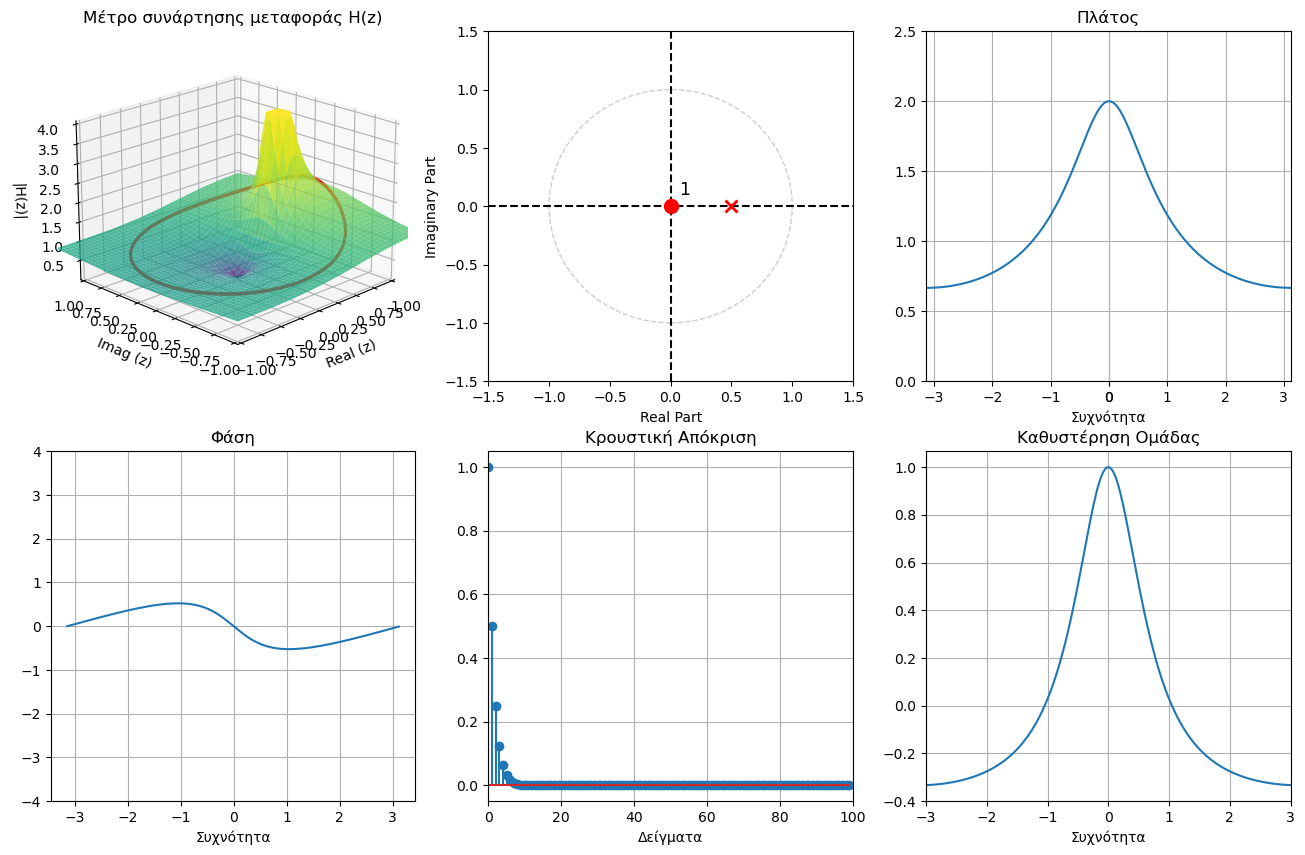

In [3]:
pezw2([1], [1, -0.5])

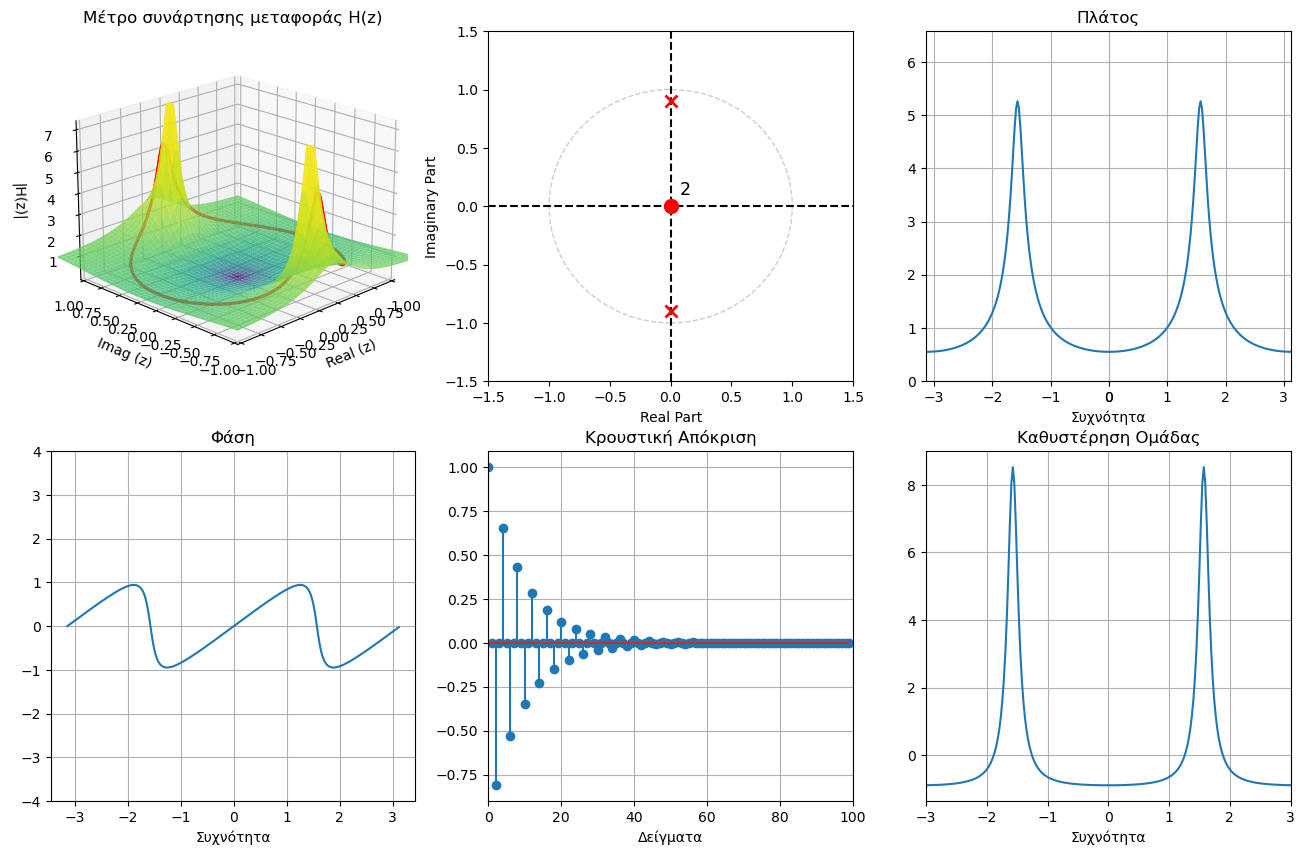

In [4]:
pezw2([1], np.convolve([1, -0.9*np.exp(1j*np.pi/2)], [1, -0.9*np.exp(-1j*np.pi/2)]))

---
---

## Άσκηση - Συστήματα Ελάχιστης Φάσης στις Τηλεπικοινωνίες
Γνωρίζετε ότι μια εφαρμογή των συστημάτων ελάχιστης φάσης βρίσκεται στις τηλεπικοινωνίες και στην κινητή τηλεφωνία. Έστω ένα απλοποιημένο σύστημα κινητής τηλεφωνίας, όπου το σήμα φωνής $x[n]$ (πομπός) υπόκειται σε μεταβολές λόγω του καναλιού επικοινωνίας $h[n]$ (το οποίο θεωρείται ένα αιτιατό και ευσταθές ΓΧΑ σύστημα), λαμβάνεται από τον σταθμό βάσης (πάροχος τηλεφωνίας) για ``καθαρισμό'', και φτάνει τελικά στο ακουστικό του παραλήπτη στη μορφή $\hat{x}[n]$ (δέκτης), η οποία πρέπει να είναι πολύ κοντά στο αρχικό $x[n]$. Σε όρους επεξεργασίας σήματος, το κανάλι του παραδείγματός μας μοντελοποιείται ως:

$$H(z) = \frac{(1 - 1.25e^{j\pi/4}z^{-1})(1 - 1.25e^{-j\pi/4}z^{-1})}{(1 - 0.97e^{j3\pi/4}z^{-1})(1 - 0.97e^{-j3\pi/4}z^{-1})}$$

δηλ. αποτελείται από δυο πόλους και δυο μηδενικά, σε συζυγή ζεύγη. Ο πάροχος τηλεφωνίας λαμβάνει αρχικά το σήμα φωνής και προτού το στείλει στον δέκτη, ανιχνεύει το κανάλι $H(z)$, και προσπαθεί να ακυρώσει την επίδραση του επάνω στο σήμα φωνής του πομπού. Δυστυχώς, διαπιστώνει ότι το σύστημα $H(z)$ δεν έχει ευσταθές και αιτιατό αντίστροφο σύστημα, οπότε πρέπει να βρει μια άλλη λύση. 

---

Χρησιμοποιώντας τις συναρτήσεις ``sig.convolve``, ``sig.lfilter``, ``pezw2``, ``wavefile.read``, ``Audio``, ακολουθήστε τα παρακάτω:

i. Παράγετε το γράφημα της ``pezw2`` για το δοθέν σύστημα $H(z)$.

<u>**Απάντηση**</u>

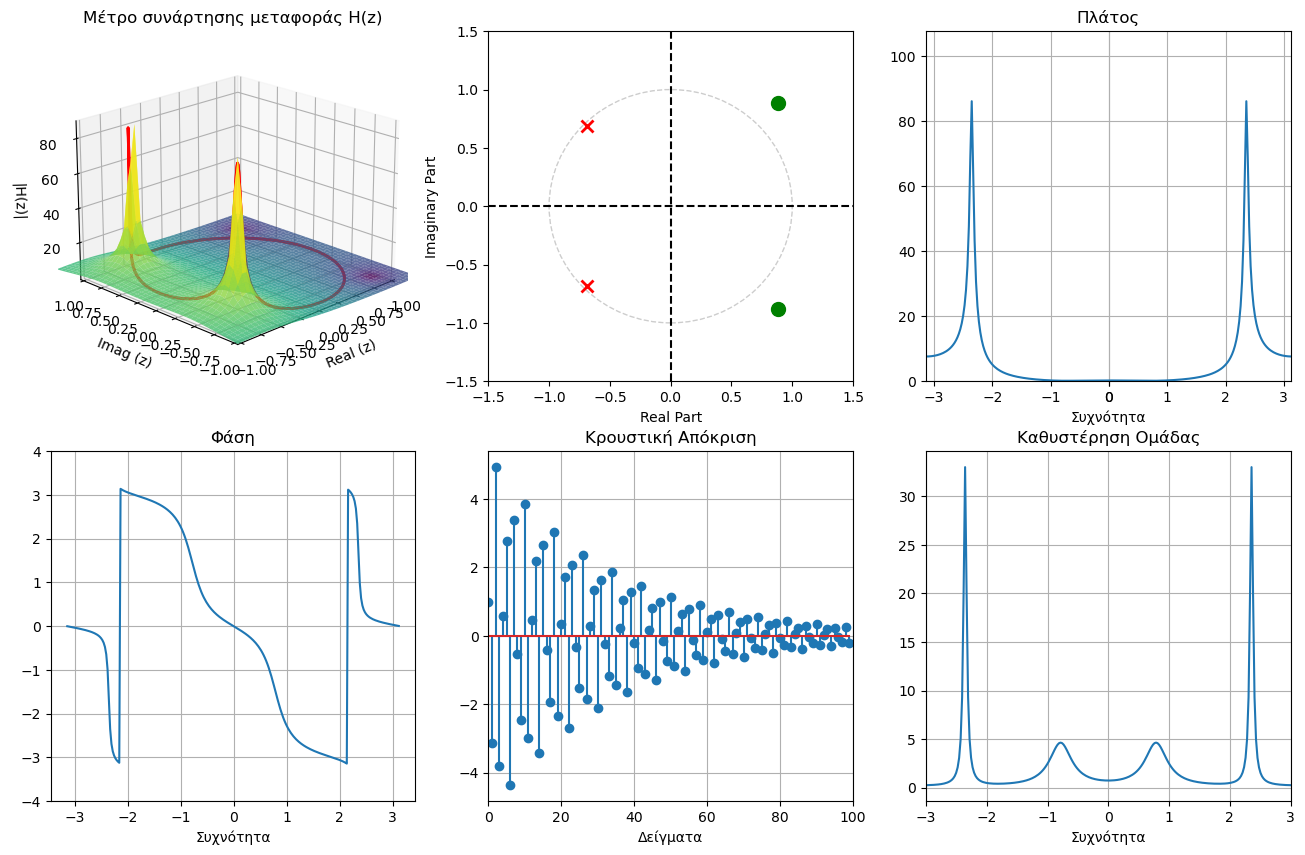

In [5]:
w0 = np.pi/4
r = 0.97

num1 = sig.convolve([1, -1.25*np.exp(1j*w0)], [1, -1.25*np.exp(-1j*w0)])
den1 = sig.convolve([1, -r*np.exp(1j*3*w0)], [1, -r*np.exp(-1j*3*w0)])

pezw2(num1, den1)

ii. Ας φορτώσουμε το αρχείο ``sampleLab3.wav`` που σας δίνεται, το οποίο είναι το σήμα φωνής που λαμβάνει ο πάροχος και πρέπει να παραδώσει καθαρό στον πελάτη-δέκτη. Ακούστε το, και δείτε το γράφημά του.

In [6]:
fs, s = wavfile.read('./files/sample.wav')     # διαβάζουμε το συνοδευτικό wav αρχείο
s = s / (2**15)                              # κανονικοποίηση

Audio(s.T, rate=fs)                          # ακούμε! :)

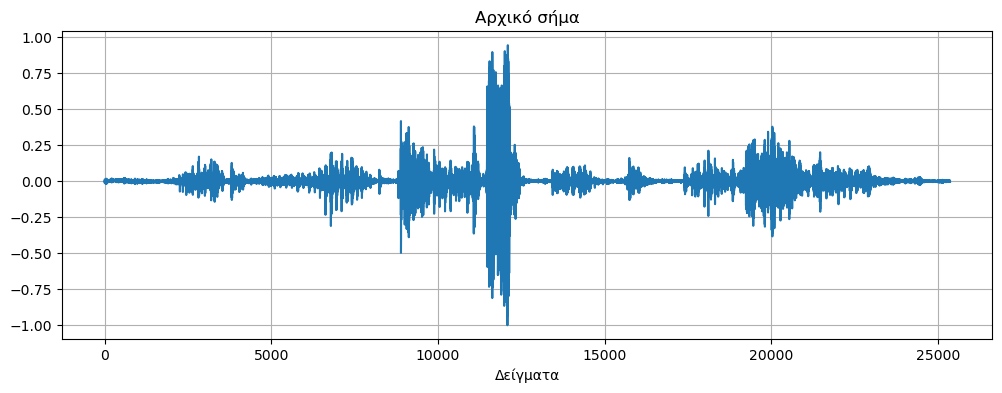

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(s)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title('Αρχικό σήμα')
plt.show()

iii. Βρείτε ένα άλλο σύστημα, $H_{min}(z)$, που να έχει την ίδια απόκριση πλάτους με το δοθέν σύστημα $H(z)$.  Εξηγήστε και γράψτε τη μαθηματική μορφή του παρακάτω. 

Καλέστε κατάλληλα τη συνάρτηση ``pezw2`` για να απεικονίσετε τα γραφήματα αυτού του συστήματος. Βεβαιωθείτε ότι όντως έχει την ίδια απόκριση πλάτους με το $H(z)$.

<u>**Απάντηση**</u>

Γνωρίζουμε από τη θεωρία ότι για να βρούμε ένα minimum-phase σύστημα, αρκεί να αλλάξουμε κάθε όρο της μορφής $1 - \alpha z^{-1}$ με $\alpha$ εκτός μοναδιαίου κύκλου με τον όρο $z^{-1} - \alpha^{*}$. Στη συγκεκριμένη περίπτωση οι όροι $$(1 - 1.25 e^{j\pi/4}z^{-1}), (1 - 1.25 e^{-j\pi/4}z^{-1})$$ θα αντικατασταθούν από τους όρους $$(z^{-1} - 1.25e^{-j\pi/4}), (z^{-1} - 1.25e^{j\pi/4})$$ αντίστοιχα. Έτσι, προκύπτει ότι το σύστημα ελάχιστης φάσης θα είναι:

$$H_{min}(z) = \frac{(z^{-1} - 1.25e^{-j\pi/4})(z^{-1} - 1.25e^{j\pi/4})}{(1 - 0.97e^{j3\pi /4}z^{-1})(1 - 0.97e^{-j3\pi /4}z^{-1})}$$

Έχουμε ήδη αποδείξει στις διαλέξεις ότι αυτό το σύστημα, με τον τρόπο που δημιουργήθηκε, θα έχει ίδια απόκριση πλάτους με αυτή του αρχικού συστήματος.


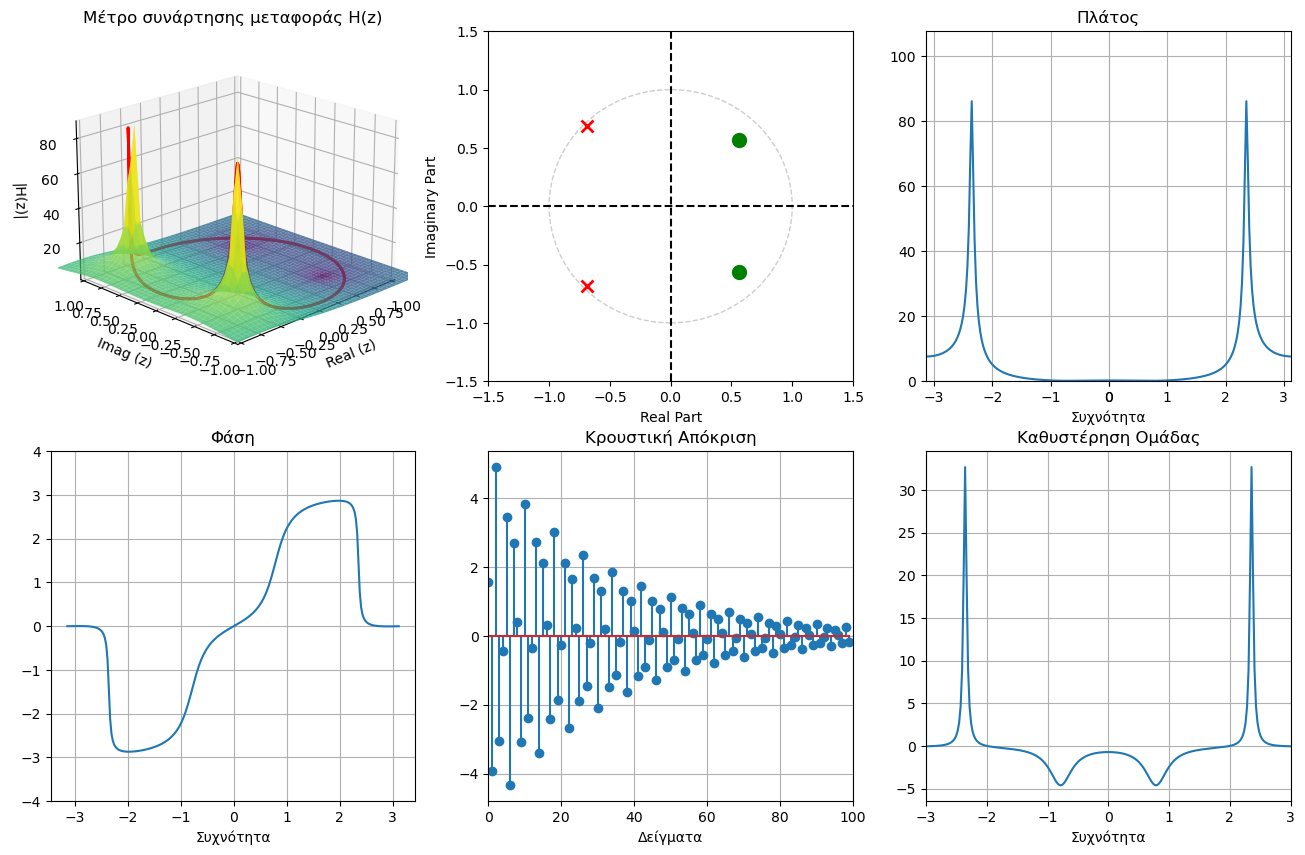

In [8]:
w0 = np.pi/4
r = 0.97

num2 = sig.convolve([-1.25*np.exp(1j*w0), 1], [-1.25*np.exp(-1j*w0), 1])
den2 = sig.convolve([1, -r*np.exp(1j*3*w0)], [1, -r*np.exp(-1j*3*w0)])

pezw2(num2, den2)

iv. Καλέστε την ``pezw2`` για να σας απεικονίσει το αντίστροφο σύστημα $H^i_{min}(z) = 1/H_{min}(z)$. Γράψτε παρακάτω πρώτα την πλήρη μαθηματική του μορφή.

<u>**Απάντηση**</u>

Θα είναι:
$$H^{i}_{min}(z) = \frac{1}{H_{min}(z)} \Longrightarrow H^{i}_{min}(z) = \frac{(1 - 0.97e^{j3\pi /4}z^{-1})(1 - 0.97e^{-j3\pi /4}z^{-1})}{(z^{-1} - 1.25e^{-j\pi/4})(z^{-1} - 1.25e^{j\pi/4})}$$


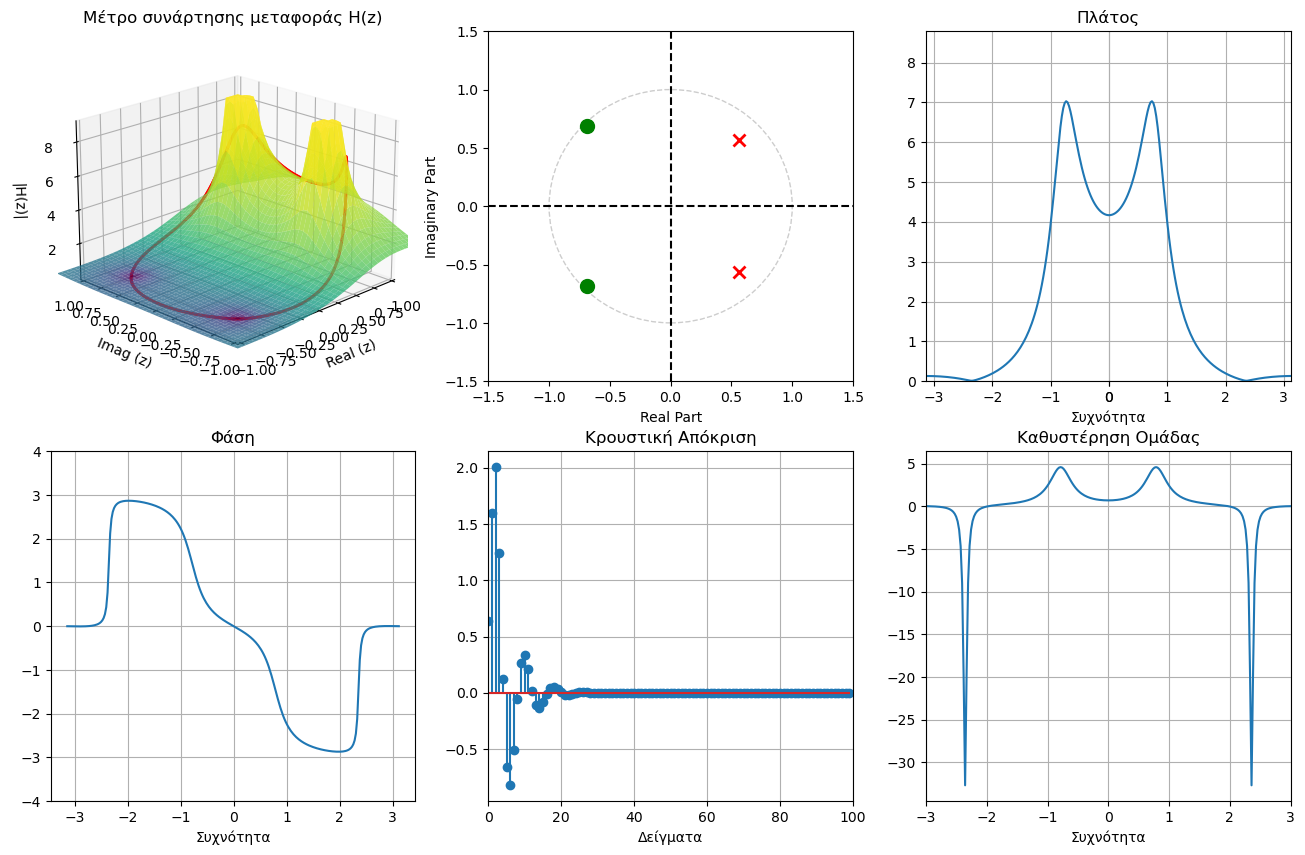

In [9]:
pezw2(den2, num2)

v. Ακυρώστε *μερικώς* την επίδραση του συστήματος $H(z)$ φιλτράροντας το σήμα που σας δίνεται μέσα από το σύστημα $H^i_{min}(z)$ που βρήκατε.

<u>**Απάντηση**</u>

In [10]:
y = sig.lfilter(den2, num2, s)

vi. Ας σχεδιάσουμε τα δυο σήματα πριν και μετά το φιλτράρισμα. Ακούστε τα. Σχολιάστε.

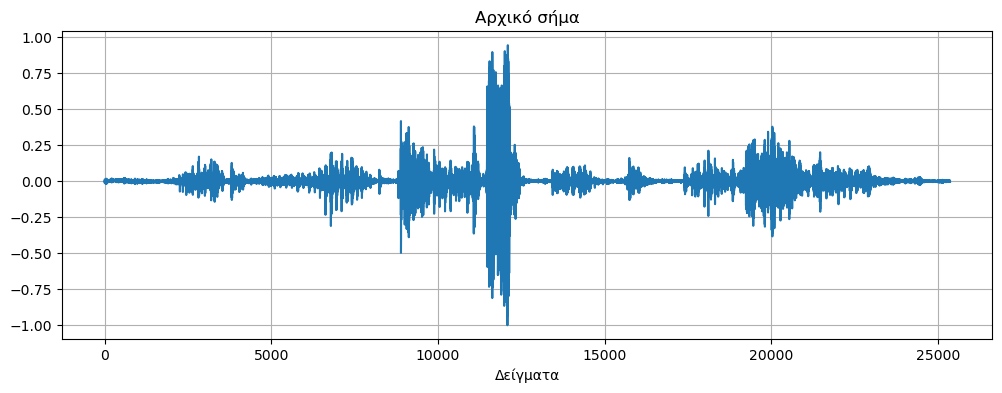

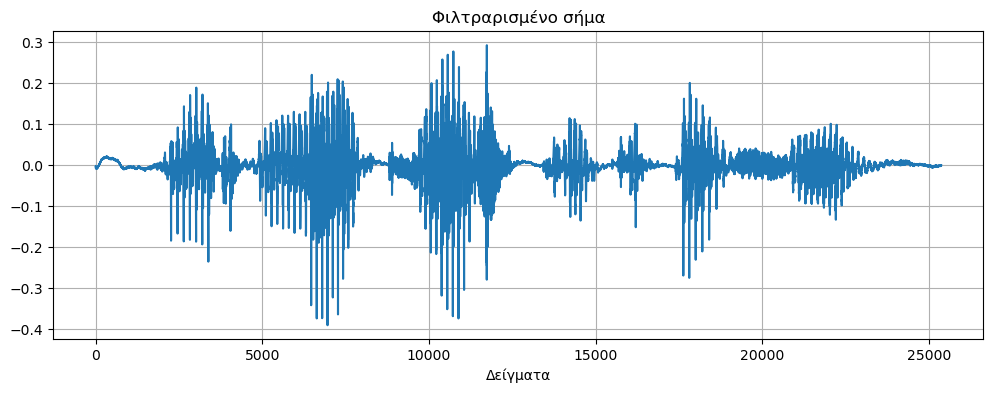

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(s)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title('Αρχικό σήμα')

plt.figure(figsize=(12, 4))
plt.plot(y)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title('Φιλτραρισμένο σήμα')

plt.show()

In [12]:
# το αρχικό
Audio(s.T, rate=fs)             # ακούμε! :)

In [13]:
# το τελικό
Audio(y.T, rate=fs)             # ακούμε! :)

Γράψτε παρακάτω το σχόλιό σας.

### Απάντηση:

Παρατηρούμε ότι το σήμα μετά το φιλτράρισμα ακούγεται πιο δυνατά, καθαρά και με πολύ λιγότερο θόρυβο, σε σχέση με το σήμα που έλαβε αρχικά ο σταθμός βάσης.


---
---